In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import norm, ttest_ind
import os, sys
sys.path.append(os.path.abspath("../src"))
from io_utils import load_data
from health_study import HealthStudyAnalizer
import statistic as S
import viz as V
import simulation as SIM
import hypothesis as H
import linear_models as L

df = load_data()
df_clean = HealthStudyAnalizer(df).clean_df()

# Beskrivande analys – Grundläggande statistik

In [2]:
stats = S.calculate_basic_stats(df_clean)
stats

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


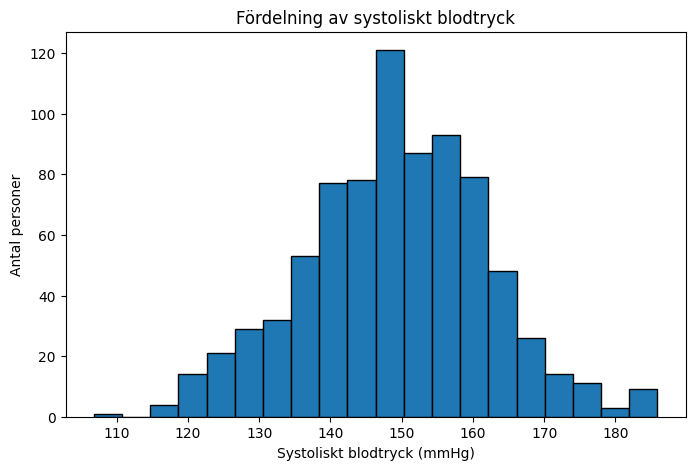

In [3]:
#Fördelning av systoliskt blodtryck graf
V.hist_distribution_systolic_blood_pressure(df_clean);

### Fördelningen av systoliskt blodtryck
- Diagrammet visar att de flesta personer har ett systoliskt blodtryck mellan 135 och 165 mmHg.
- Majoriteten ligger runt 145–150 mmHg, vilket visar den vanligaste nivån i gruppen.

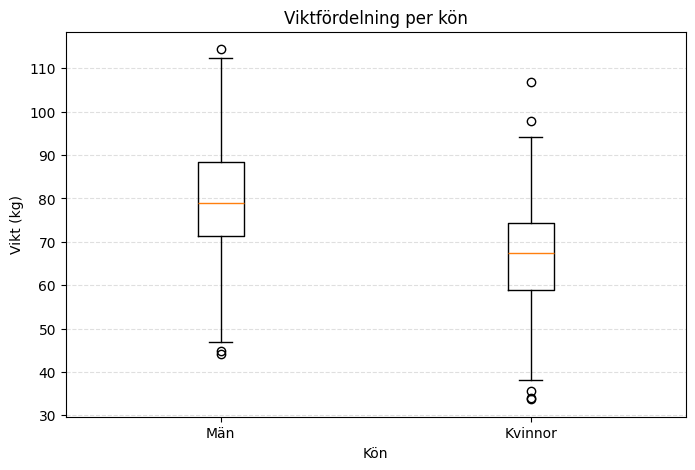

In [4]:
#Viktfördelning per kön graf
V.boxplot_distribution_weight_by_gender((df_clean));

### Viktfördelning per kön
- Diagrammet visar att män i genomsnitt väger mer än kvinnor.
- Medianvikten för män ligger runt 78–80 kg, medan kvinnors medianvikt ligger runt 65–68 kg.
- Spridningen är också något större bland män.
- Några outliers finns för båda könen, både lägre och högre vikter än genomsnittet.

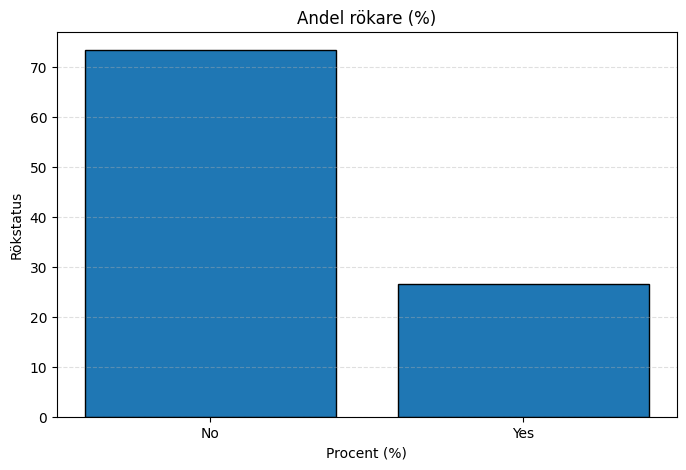

In [5]:
#Andel rökare graf
V.bar_percentage_smokers(df_clean);

### Andelen rökare
- Diagrammet visar att majoriteten av populationen inte röker, vilket kan ha en positiv inverkan på deras hälsa.

# Simulering och jämförelse av sjukdomsandel

In [6]:
disease_rate, disease_rate_percent = S.calculate_disease_rate(df_clean)
print(f"Andelen personer med sjukdom: {disease_rate_percent:.2}")

simulated_rate = SIM.simulate_disease_rate(disease_rate)
print(f"Andelen personer med sjukdom i simuleringen: {simulated_rate:.2%}")

Andelen personer med sjukdom: 5.9
Andelen personer med sjukdom i simuleringen: 5.60%


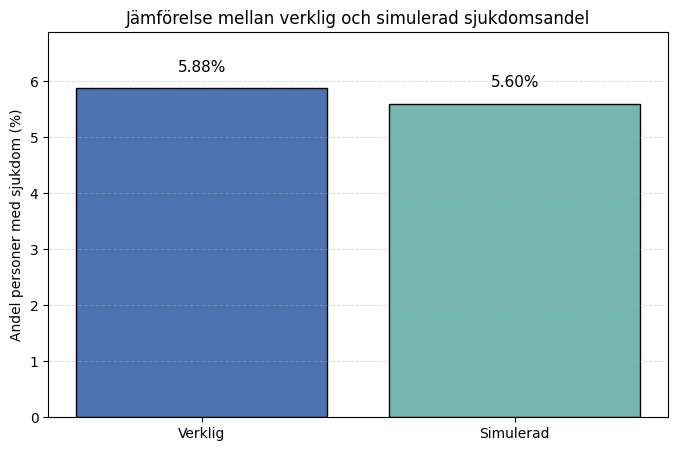

In [7]:
#Jämförelse mellan verklig och simulerad sjukdomsandel
values = [disease_rate_percent, simulated_rate * 100] 
V.bar_real_vs_simulated(df_clean, values);

### Jämförelse mellan verklig och simulerad sjukdomsandel
- Den simulerade andelen (5,60%) ligger mycket nära den verkliga andelen (5,88%), vilket visar att simuleringen stämmer väl överens med verkligheten.

In [8]:
x = df_clean["systolic_bp"].values
ci_norm_low, ci_norm_high = H.ci_normal(x)
ci_boot_low, ci_boot_high = H.ci_bootstrap(x)
ci_table = S.compare_ci(
    (ci_norm_low, ci_norm_high),
    (ci_boot_low, ci_boot_high)
)
print("95% konfidensintervall för systolic_bp\n")
print(ci_table)


95% konfidensintervall för systolic_bp

               Low     High
Normal     148.292  150.065
Bootstrap  148.314  150.087


## Jämförelse av konfidensintervall

- Normalapproximationen och bootstrapmetoden ger nästan identiska intervall, skillnaderna mellan de två metoderna är minimala, vilket tyder på att skattningen är stabil och inte känslig för valet av metod.

In [9]:
res = H.one_sided_ttest_smoking(df_clean)
print("Medel blodtryck (rökare):", round(res["mean_smokers"], 3))
print("Medel blodtryck (icke-rökare):", round(res["mean_non_smokers"], 3))
print("t-statistik:", round(res["t_stat"], 3))
print("p-värde:", round(res["p_value"], 3))

Medel blodtryck (rökare): 149.525
Medel blodtryck (icke-rökare): 149.053
t-statistik: 0.461
p-värde: 0.322


In [10]:
res_boot = H.bootstrap_ttest_smoking(df_clean)
print("Observerad skillnad:", round(res_boot["obs_diff"], 3))
print("p-värde:", round(res_boot["p_value"], 3))
print("Bootstrap CI:", (round(res_boot["ci_low"], 3), round(res_boot["ci_high"], 3)))

Observerad skillnad: 0.472
p-värde: 0.499
Bootstrap CI: (np.float64(-1.56), np.float64(2.499))


## Kort förklaring (Bootstrap + t-test)

- Både t-testet och bootstrap-analysen visar att skillnaden i medel-blodtryck mellan rökare och icke-rökare är mycket liten och inte statistiskt signifikant. Det observerade medelvärdesskillnaden är nära noll, p-värdena är höga och konfidensintervallet innehåller noll.
Vi kan därför inte dra slutsatsen att rökare har högre blodtryck i detta dataset.

In [11]:
LM = L.HealthLinearModels(df_clean)
model, result = LM.linear_regression_bp()
result


{'intercept': np.float64(109.49908144566376),
 'coefficients': array([0.53892763, 0.17765752]),
 'pred_first_5': array([151.91, 151.87, 155.9 , 164.84, 152.78])}

Modellen är en enkel linjär regression som predicerar systoliskt blodtryck baserat på ålder och vikt. 

- **Intercept (109.5)**: Det förväntade blodtrycket när ålder och vikt är noll.  
- **Koefﬁcienter**:  
  - Ålder (0.54): Varje extra år ökar blodtrycket med ca 0.54 mmHg.  
  - Vikt (0.18): Varje extra kilo ökar blodtrycket med ca 0.18 mmHg.  
- **Förutsägelser för de första 5 individerna**: [151.91, 151.87, 155.9, 164.84, 152.78]


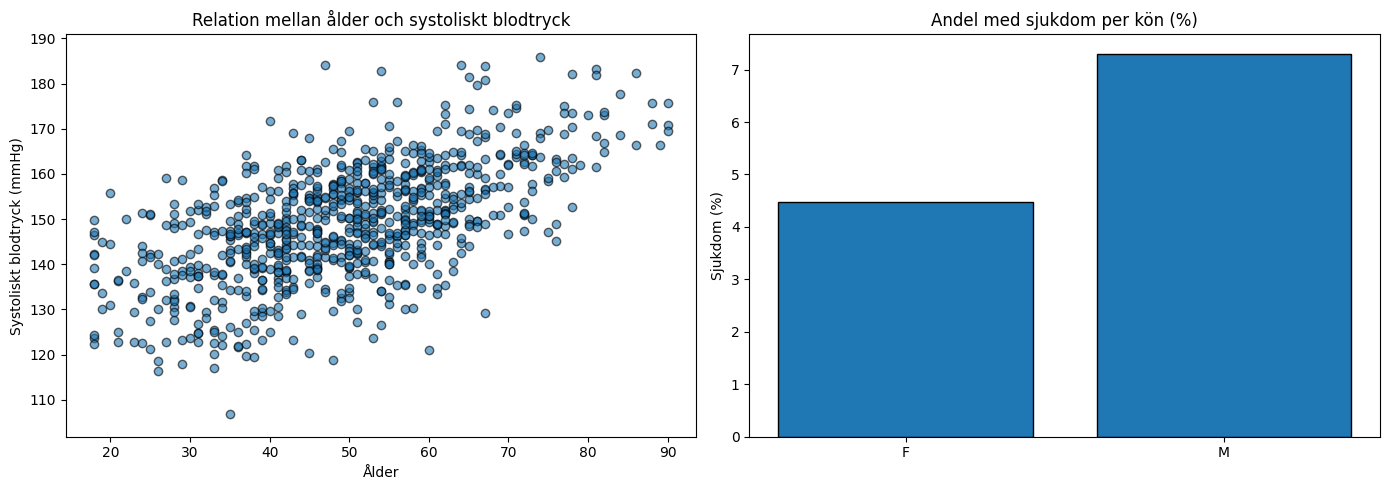

In [12]:
V.extended_visualization(df_clean);